In [1]:
import pickle

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from catboost import CatBoostClassifier



In [4]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline


In [5]:
train_df = pd.read_json('dataset_train.json')
test_df = pd.read_json('dataset_test.json')

In [6]:
def upnack_consumption(df):
    for month in range(1, 13):
        month_str = str(month)
        df[f'consumption_{month_str}'] = df['consumption'].apply(
            lambda x: x.get(month_str, 0) if isinstance(x, dict) else 0
        )


    df = df.drop('consumption', axis=1)

    return df

train_df = upnack_consumption(train_df)
test_df = upnack_consumption(test_df)



In [7]:
def mean_consumption(row):
    return row.mean()

train_df['mean'] = train_df.loc[:,'consumption_1':'consumption_12'].apply(mean_consumption, axis=1)
test_df['mean'] = test_df.loc[:,'consumption_1':'consumption_12'].apply(mean_consumption, axis=1)

In [8]:
def std_consumption(row):
    return row.std(ddof=0)

train_df['std'] = train_df.loc[:,'consumption_1':'consumption_12'].apply(std_consumption, axis=1)
test_df['std'] = test_df.loc[:,'consumption_1':'consumption_12'].apply(std_consumption, axis=1)

In [9]:
def coefficient_of_variation(row):  # Коэффициент вариативности (отношение стандартного отклонения к среднему)
    mean_val = row.mean()
    std_val = row.std(ddof=0)  # ddof=0 для расчета по всей совокупности
    if mean_val != 0:
        return std_val / mean_val
    else:
        return 0  # или np.nan, если среднее равно 0

train_df['cv'] = train_df.loc[:,'consumption_1':'consumption_12'].apply(coefficient_of_variation, axis=1)
test_df['cv'] = test_df.loc[:,'consumption_1':'consumption_12'].apply(coefficient_of_variation, axis=1)

In [10]:
def sum_consumption(row):
    return row.sum()

train_df['sum'] = train_df.loc[:,'consumption_1':'consumption_12'].apply(sum_consumption, axis=1)
test_df['sum'] = test_df.loc[:,'consumption_1':'consumption_12'].apply(sum_consumption, axis=1)

In [11]:
def min_consumption(row):
    return row.min()

train_df['min'] = train_df.loc[:,'consumption_1':'consumption_12'].apply(min_consumption, axis=1)
test_df['min'] = test_df.loc[:,'consumption_1':'consumption_12'].apply(min_consumption, axis=1)

In [12]:
def max_consumption(row):
    return row.max(axis=1)

train_df['max'] = train_df.loc[:,'consumption_1':'consumption_12'].apply(min_consumption, axis=1)
test_df['max'] = test_df.loc[:,'consumption_1':'consumption_12'].apply(min_consumption, axis=1)

In [13]:

train_df['rooms_per_person'] = train_df['roomsCount'].div(train_df['residentsCount'])
test_df['rooms_per_person'] = test_df['roomsCount'].div(test_df['residentsCount'])
    

In [14]:
def average_for_season(df):
    window = 3
    for i in range(1, 12, window):
        df[f'season_average_{int(i/3) + 1}'] = df.loc[:,f'consumption_{i}':f'consumption_{i+window - 1}'].mean(axis=1)
    
    return df

train_df = average_for_season(train_df)
test_df = average_for_season(test_df)

In [15]:
def diff_two_mounth(df):
    for i in range(1, 12):
        df[f'diff_{i}'] = df[f'consumption_{i}'] - df[f'consumption_{i+1}']
        df[f'diff_{i}'] = df[f'diff_{i}'].abs()
    return df

train_df = diff_two_mounth(train_df)
test_df = diff_two_mounth(test_df)

In [16]:
%matplotlib inline

In [17]:
train_df.T.head(50)

,0,1,2,3,4,5,6,7,8,9,...,4816,4817,4818,4819,4820,4821,4822,4823,4824,4825
accountId,1497,1509,1674,1955,1960,1968,1969,1971,1973,1976,...,7317,7318,7319,7320,7321,7322,7323,7324,7325,7326
isCommercial,True,True,True,True,True,True,True,True,True,True,...,False,False,True,False,True,True,True,False,False,False
address,"Краснодарский край, р-н Мостовский, пгт Мостов...","Краснодарский край, р-н Усть-Лабинский, х Брат...","Краснодарский край, р-н Тбилисский, ст-ца Тбил...","Краснодарский край, р-н Анапский, с Сукко, ул ...","Краснодарский край, р-н Анапский, село Витязев...","Краснодарский край, р-н Анапский, село Витязев...","Краснодарский край, р-н Крымский, х Веселый (М...","Краснодарский край, р-н Анапский, село Витязев...","Краснодарский край, г Геленджик, с Архипо-Осип...","Краснодарский край, г Геленджик, с Архипо-Осип...",...,"Краснодарский край, г Новороссийск, с Южная Оз...","Краснодарский край, р-н Белореченский, п Родни...","Краснодарский край, г Сочи, с Мамедова Щель, у...","Краснодарский край, г Сочи, с Волконка, ул Оль...","Краснодарский край, г Сочи, ПОС. АШЕ, ул Репин...","Краснодарский край, г Сочи, ПОС. ЛАЗАРЕВСКОЕ, ...","Краснодарский край, г Сочи, с Якорная Щель, ул...","Краснодарский край, г Сочи, ПОС. ЛАЗАРЕВСКОЕ, ...","Краснодарский край, г Сочи, пос Лоо, ул Отрадн...","Краснодарский край, г Сочи, пос Н. Беранда, ул..."
buildingType,Частный,Частный,Частный,Частный,Частный,Частный,Частный,Частный,Частный,Частный,...,Частный,Прочий,Частный,Частный,Частный,Частный,Многоквартирный,Частный,Частный,Частный
roomsCount,1.0,1.0,3.0,5.0,3.0,15.0,2.0,3.0,15.0,3.0,...,4.0,NaN,3.0,4.0,3.0,3.0,1.0,3.0,5.0,3.0
residentsCount,1.0,1.0,2.0,1.0,3.0,3.0,1.0,3.0,3.0,1.0,...,NaN,NaN,3.0,1.0,3.0,3.0,1.0,3.0,6.0,1.0
totalArea,NaN,NaN,80.5,908.0,NaN,NaN,33.8,873.7,689.8,NaN,...,438.9,NaN,NaN,164.8,NaN,644.2,23.9,NaN,454.0,1313.4
consumption_1,3484,3756,1543,5564,631,320,125,1249,1360,0,...,1560,7652,10458,4991,1148,306,351,4228,3940,12306
consumption_2,2824,1580,1075,6201,616,460,125,925,1870,0,...,7920,7464,4191,4683,378,312,80,4291,2899,9159
consumption_3,3035,3191,2344,5364,439,380,125,1449,1781,0,...,0,6660,4989,2922,169,501,229,5528,2284,8320


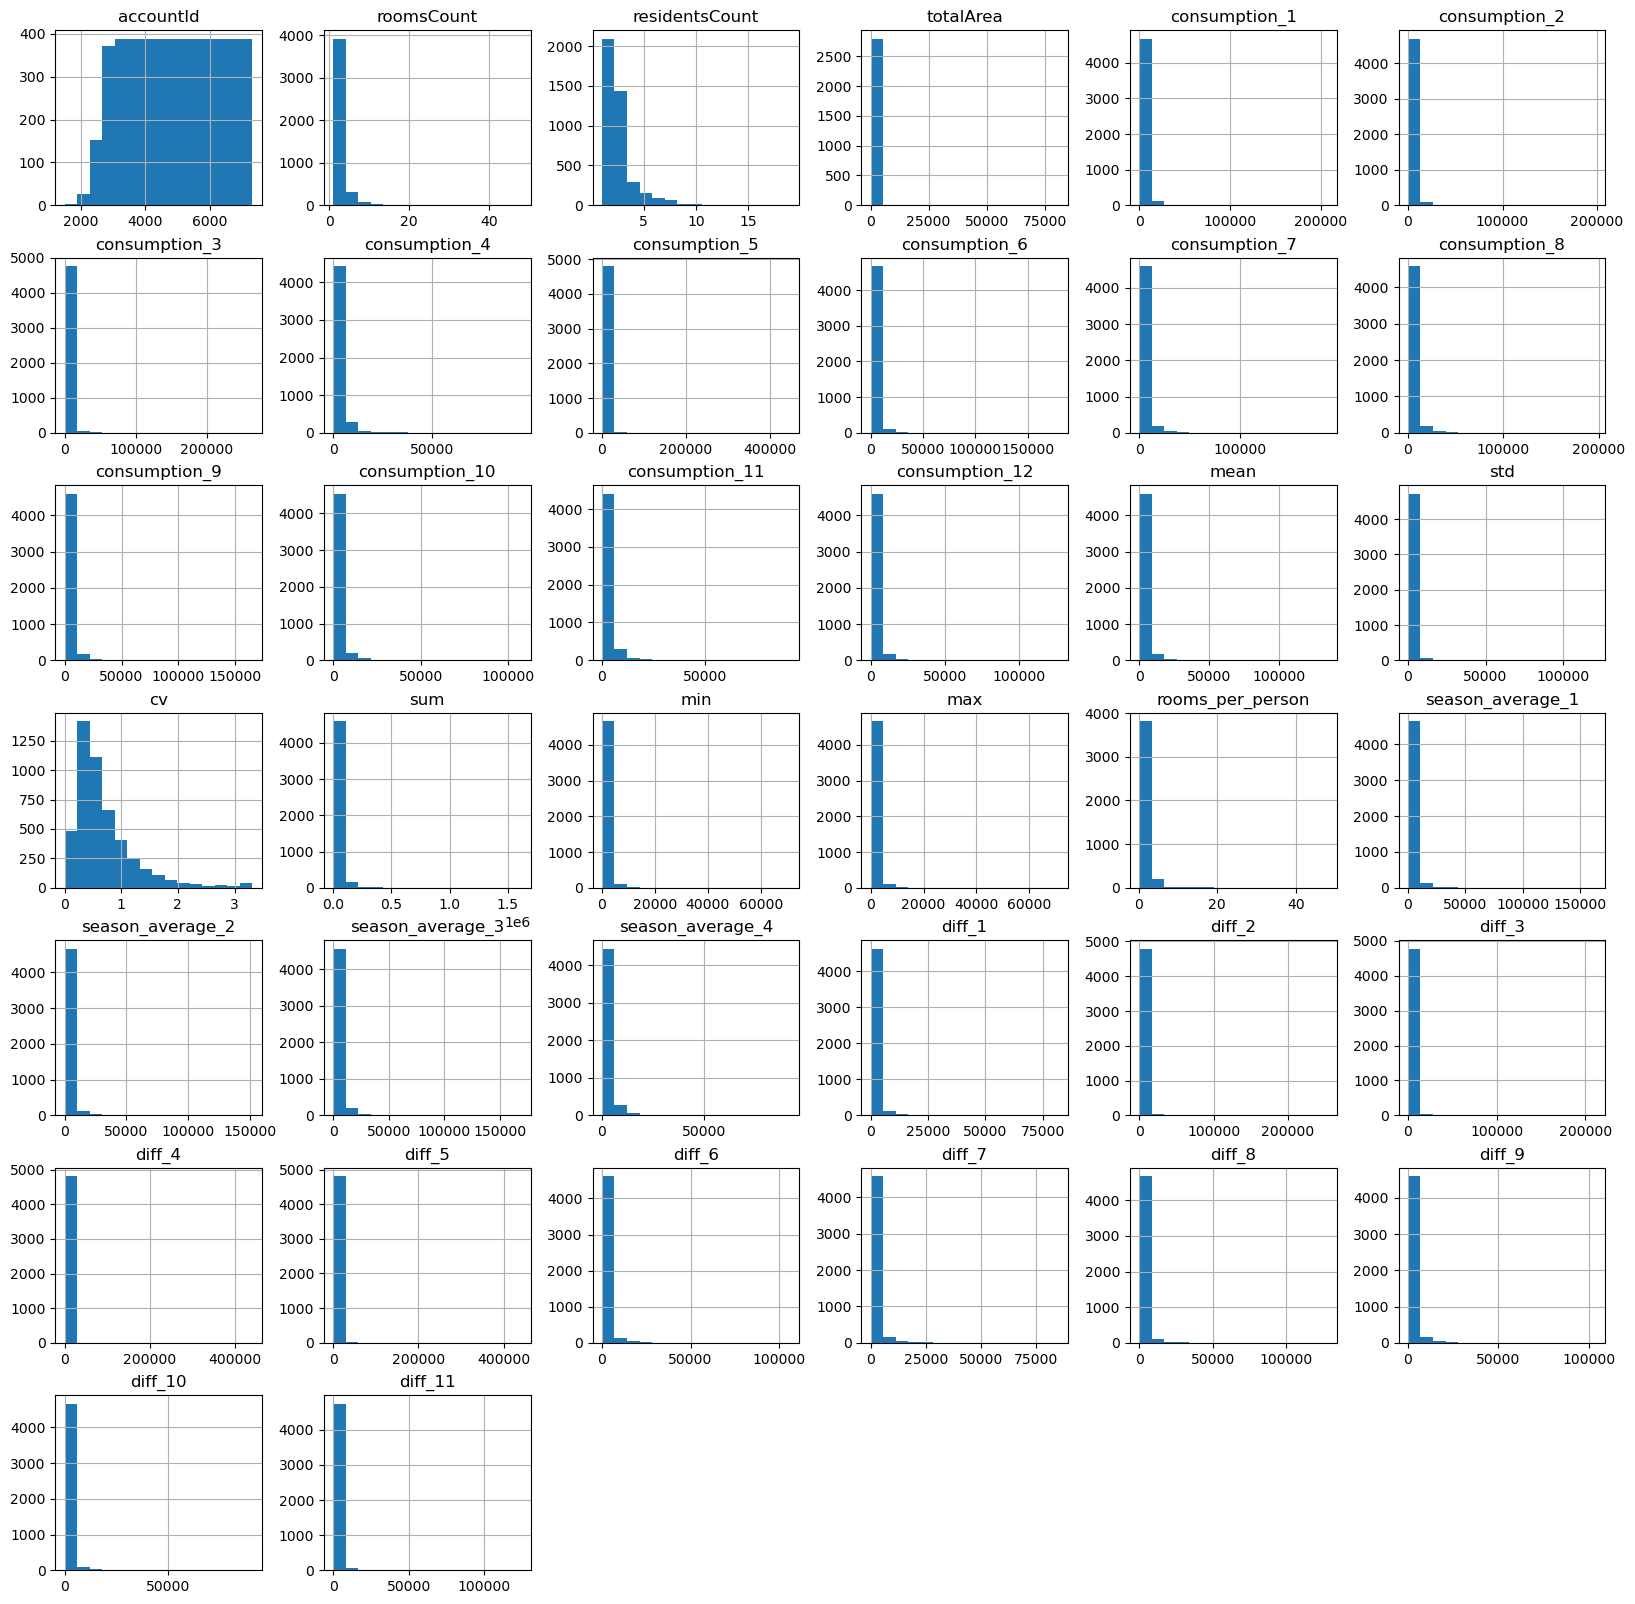

In [18]:
train_df.hist(figsize=(20,20), bins=15)
plt.show()

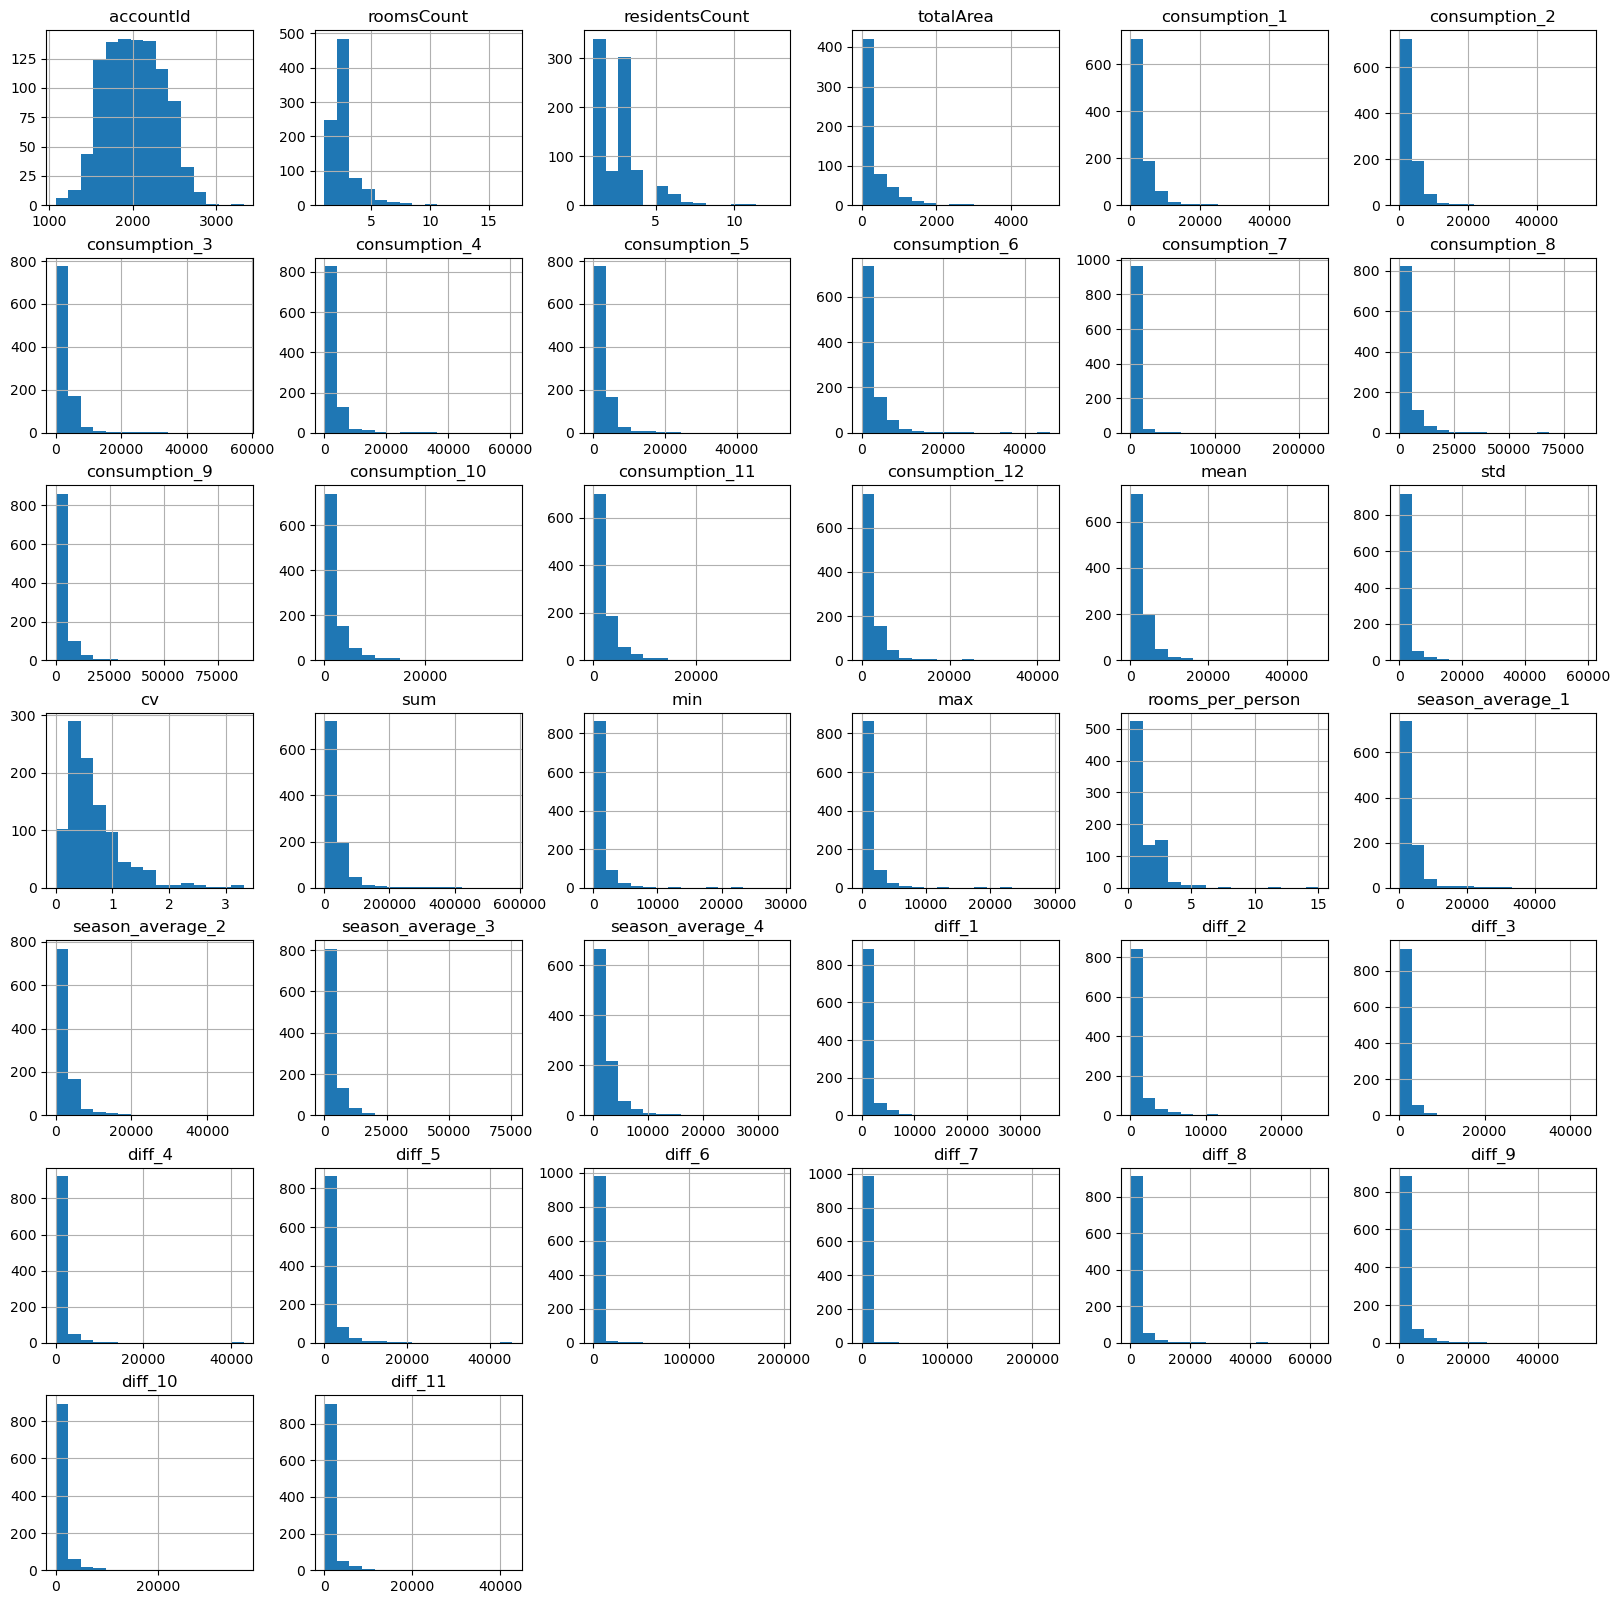

In [19]:
test_df.hist(figsize=(20,20), bins=15)
plt.show()

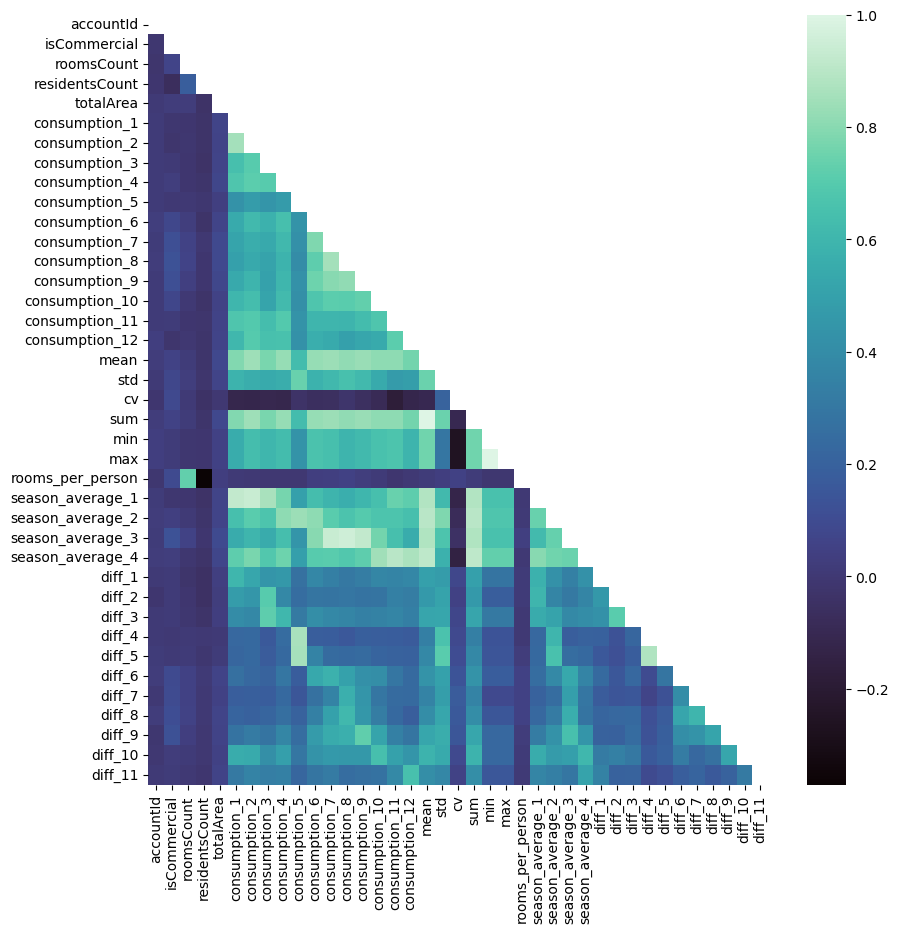

In [20]:
plt.figure(figsize=(10, 10))
colums = list(train_df)
colums.remove('address')
colums.remove('buildingType')

mask = np.triu(train_df.loc[:,colums].corr())
sns.heatmap(train_df.loc[:,colums].corr(), cmap="mako", mask=mask)
plt.show()

In [21]:
train_df["rooms_per_person"].describe()

count    4090.000000
mean        1.745320
std         1.916535
min         0.125000
25%         1.000000
50%         1.000000
75%         2.000000
max        48.000000
Name: rooms_per_person, dtype: float64

In [22]:
X_train = train_df.drop('isCommercial', axis=1)
y_train = train_df["isCommercial"]


X_test = test_df.drop('isCommercial', axis=1)
y_test = test_df["isCommercial"]

In [23]:
categorical_features = ['buildingType']
numerical_features = [
    'roomsCount',
    'residentsCount',
    'totalArea',
    #'consumption_1',
    #'consumption_2',
    #'consumption_3',
    #'consumption_4',
    #'consumption_5',
    #'consumption_6',
    #'consumption_7',
    #'consumption_8',
    #'consumption_9',
    #'consumption_10',
    #'consumption_11',
    #'consumption_12',
    #'season_average_1',
    #'season_average_2',
    #'season_average_3',
    #'season_average_4',
    'rooms_per_person',
    'diff_1',
    'diff_2',
    'diff_3',
    'diff_4',
    'diff_5',
    'diff_6',
    'diff_7',
    'diff_8',
    'diff_9',
    'diff_10',
    'diff_11',
  # 'mean',
   # 'std',
    'cv',
  # 'sum',
    'min',
    'max',
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='mean'), numerical_features),
        #('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(), categorical_features),
    ]
)

In [317]:
pipeline_random_forest = Pipeline(steps=[
    ('preprocessor', preprocessor),    
    #('classifier', LogisticRegression(penalty="l1", solver="liblinear", C=1.0))
    ('classifier', RandomForestClassifier(random_state=42, criterion='entropy', n_estimators=10000, max_depth=100, min_samples_split=5)),
])

In [318]:
pipeline_random_forest.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', SimpleImputer(),
                                                  ['roomsCount',
                                                   'residentsCount',
                                                   'totalArea',
                                                   'rooms_per_person', 'diff_1',
                                                   'diff_2', 'diff_3', 'diff_4',
                                                   'diff_5', 'diff_6', 'diff_7',
                                                   'diff_8', 'diff_9',
                                                   'diff_10', 'diff_11', 'cv',
                                                   'min', 'max']),
                                                 ('cat', OneHotEncoder(),
                                                  ['buildingType'])])),
                ('classifier',
                 RandomForestClassifier(criterion='entropy', max_depth=100,
                                        min_samples_split=5, n_estimators=10000,
                                        random_state=42))])

In [319]:
y_pred = pipeline_random_forest.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.73      0.87      0.79       608
        True       0.71      0.50      0.59       392

    accuracy                           0.73      1000
   macro avg       0.72      0.69      0.69      1000
weighted avg       0.72      0.73      0.71      1000



In [286]:
pipeline_gradient_boosting = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42, learning_rate=0.01)),
])

pipeline_gradient_boosting.fit(X_train, y_train)



              precision    recall  f1-score   support

       False       0.66      0.94      0.77       608
        True       0.72      0.25      0.37       392

    accuracy                           0.67      1000
   macro avg       0.69      0.59      0.57      1000
weighted avg       0.68      0.67      0.61      1000



In [ ]:
pipeline_cat_boost = Pipeline([
('preprocessor', preprocessor),
('clf', CatBoostClassifier(iterations=1000000, depth=8, learning_rate=10**(-3), verbose=1))
])

pipeline_cat_boost.fit(X_train, y_train)



0:	learn: 0.6929560	total: 59.3ms	remaining: 16h 27m 45s
1:	learn: 0.6927402	total: 66ms	remaining: 9h 10m 5s
2:	learn: 0.6925617	total: 73.2ms	remaining: 6h 46m 26s
3:	learn: 0.6923584	total: 80.9ms	remaining: 5h 37m 2s
4:	learn: 0.6921798	total: 88.4ms	remaining: 4h 54m 41s
5:	learn: 0.6919701	total: 95.7ms	remaining: 4h 25m 48s
6:	learn: 0.6917833	total: 103ms	remaining: 4h 5m 14s
7:	learn: 0.6915792	total: 111ms	remaining: 3h 50m 28s
8:	learn: 0.6913755	total: 118ms	remaining: 3h 37m 41s
9:	learn: 0.6911553	total: 125ms	remaining: 3h 28m 9s
10:	learn: 0.6909478	total: 132ms	remaining: 3h 20m 7s
11:	learn: 0.6907608	total: 139ms	remaining: 3h 13m 14s
12:	learn: 0.6905809	total: 146ms	remaining: 3h 7m 14s
13:	learn: 0.6903732	total: 153ms	remaining: 3h 2m 37s
14:	learn: 0.6901573	total: 161ms	remaining: 2h 58m 42s
15:	learn: 0.6899524	total: 168ms	remaining: 2h 54m 55s
16:	learn: 0.6897506	total: 176ms	remaining: 2h 52m 12s
17:	learn: 0.6895621	total: 183ms	remaining: 2h 49m 19s
18:	

In [ ]:
y_pred = pipeline_cat_boost.predict(X_test)
print(classification_report(y_test, y_pred))

In [ ]:
def pipeline_to_json(pipeline, file=None):
    if file is not None:
        pickle.dump(pipeline, file)
        
    return pickle.dumps(pipeline)


def json_to_pipeline(file):
    return load(file)